In [ ]:
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 


usage: ipykernel_launcher.py [-h] config_path
ipykernel_launcher.py: error: the following arguments are required: config_path


SystemExit: 2

/home/bela/miniconda3/envs/thesis/lib/python3.12/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [15]:
preds_dir = '../preds/'
dataset_dir = '../data/'

In [22]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset

def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

In [23]:
files = os.listdir(preds_dir)
print(files)

['output_1985_2x.pt']


# Ground Truth

In [25]:
dataset = load_dataset(dataset_dir + 'era5_training.nc',
                       start='1980-01-01', 
                       end='1984-12-31', 
                       patch_size=32)

train_split = dataset.sel(valid_time=slice('1980-01-01', '1982-12-31'))
eval_split = dataset.sel(valid_time=slice('1984-01-01', '1984-12-31'))

_, scale = normalize_data(train_split)
eval_split, _ = normalize_data(eval_split, scale)

ground_truth_wind_speeds = np.sqrt(eval_split['u10'].values**2 + eval_split['v10'].values**2)
print(ground_truth_wind_speeds.shape)


(1464, 32, 32)


# Low res input

In [29]:
lr_fields = []
for i in range(eval_split['u10'].shape[0]):
    lr_fields.append(average_pooling(eval_split['u10'][i].values, 2, False))
    lr_fields.append(average_pooling(eval_split['v10'][i].values, 2, False))

lr_fields = np.stack(lr_fields, axis=0)
lr_fields.shape
# get windspeed
lr_wind_speeds = np.sqrt(lr_fields[::2]**2 + lr_fields[1::2]**2)
print(lr_wind_speeds.shape)

(1464, 16, 16)


# Model Output

In [10]:
for file in files:
    if not file.endswith('.pt'):
        continue
    field = torch.load(preds_dir + file, weights_only=False)
    print(field.shape)
    wind_speed_fields = torch.sqrt(field[:, 0, :, :]**2 + field[:, 1, :, :]**2)
    print(wind_speed_fields.shape)
    

torch.Size([1464, 2, 32, 32])
torch.Size([1464, 32, 32])


# Compare 


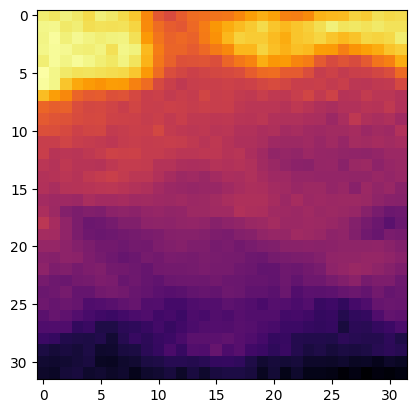

In [ ]:
# plot last wind speed field as cmap for gt, lr, and sr
fig, ax 
